#**Capstone Project | Fraud Detection Analysis**

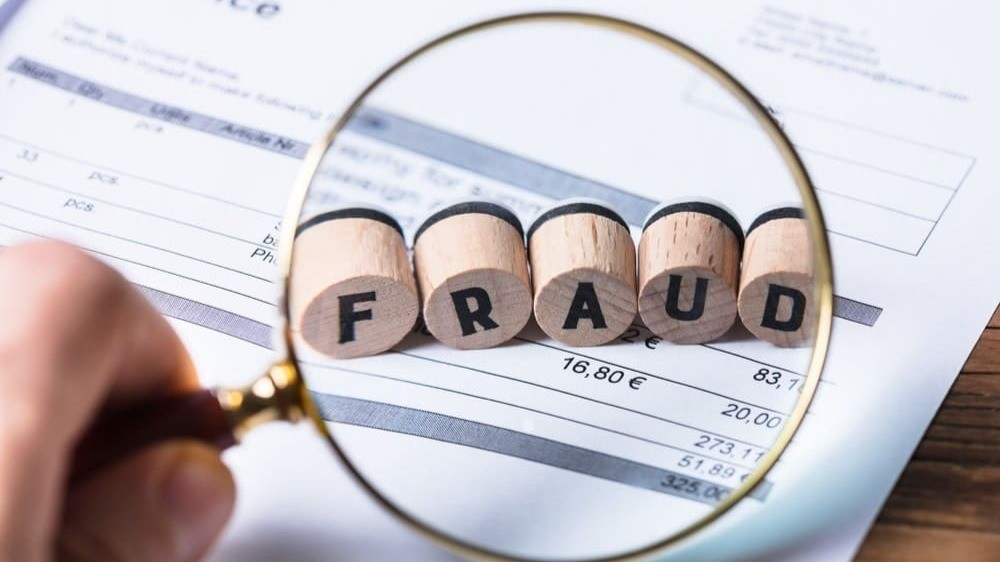

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h3 align="left"><font color=red>Problem:</font></h3>
This project aims to enhance the accuracy of detecting fraud in mobile financial transactions. By leveraging machine learning, the project seeks to predict fraudulent transactions with high precision. The goal is to develop a robust machine learning model to accurately identify fraudulent transactions in real-time , enabling the company to improve security, reduce financial losses, and gain insights into factors contributing to transaction fraud.

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Objectives:</font></h3>

* __Explore the Dataset__: Uncover patterns, distributions, and relationships within the data.
* __Conduct Extensive Exploratory Data Analysis (EDA)__: Dive deep into bivariate relationships against the target.
* __Preprocessing Steps__:
  - Remove irrelevant features
  - Address missing values
  - Treat outliers
  - Encode categorical variables
  - Transform skewed features to achieve normal-like distributions
* __Model Building__:
  - Establish pipelines for models that require scaling
  - Implement and tune classification models including Logistic Regression, SVM, Decision Trees, and Random Forest
  - Emphasize achieving high recall for class 1, ensuring comprehensive identification of heart patients
* __Evaluate and Compare Model Performance__: Utilize precision, recall, and F1-score to gauge models' effectiveness.


##Step 1 :- Importing Liberies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import ipywidgets as widgets
from IPython.display import display, HTML

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

##Step 2 :- Loading the Dataset

In [ ]:
# Read dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Fraud_Analysis_Dataset.csv")

Saving Fraud_Analysis_Dataset.csv to Fraud_Analysis_Dataset.csv


##Step 3 :- Dataset Overview

###3.1. Original Dataset Overview

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [ ]:
df.shape

(11142, 10)

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h2 align="left"><font color=red>Dataset Description:</font></h2>
    
| __Variable__ | __Description__ |
|     :---      |       :---      |      
| __step__ | maps a unit of time in the real world. In this case 1 step is 1 hour of time. |
| __type__ | Types of transactions: <br>CASH-IN: Refers to depositing cash into an account, typically adding funds.<br>CASH-OUT: Refers to withdrawing cash from an account, usually removing funds.<br>DEBIT: This can have two meanings: <br>-> It can refer to a decrease in the balance of a financial account due to a withdrawal or an expense; <br>-> In accounting, it represents an entry that reduces assets or increases liabilities.<br>PAYMENT: Refers to the transfer of money from one party (payer) to another (payee) in exchange for <br>goods, services, or as settlement of a debt.<br>TRANSFER: Refers to moving money from one account to another, often between accounts held by<br> the same person or entity. |
| __amount__ | amount of the transaction in local currency. |
| __nameOrig__ | customer who started the transaction |
| __oldbalanceOrg__ | initial balance before the transaction |                     
| __newbalanceOrig__ | new balance after the transaction. |
| __nameDest__ | customer who is the recipient of the transaction |  
| __oldbalanceDest__ | initial balance recipient before the transaction.<br> Note that there is no information for customers that start with M (Merchants). |                      
| __newbalanceDest__ | new balance recipient after the transaction. <br>Note that there is no information for customers that start with M (Merchants). |
| __isFraud__ | This is the transactions made by the fraudulent agents inside the simulation.<br> In this specific dataset the fraudulent behavior of the agents aims to profit by taking control of <br> customers accounts and try to empty the funds by transferring to another account and then <br> cashing out of the system.<br>(0: Not a Fraud; 1: Is a Fraud) |

Since there is no information related to customers that start with M(Merchants), droping rows where nameDest starts with M and assigning it into new dataframe for further analysis

In [ ]:
df_filtered = df[~df['nameDest'].str.startswith('M')].copy()

In [ ]:
df_filtered.shape

(5632, 10)

###3.2. Filtered Dataset Overview

In [ ]:
df_filtered.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


###3.3. Basic Information

In [ ]:
# Display a cocise summary of a DataFrame
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5632 entries, 0 to 11139
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            5632 non-null   int64  
 1   type            5632 non-null   object 
 2   amount          5632 non-null   float64
 3   nameOrig        5632 non-null   object 
 4   oldbalanceOrg   5632 non-null   float64
 5   newbalanceOrig  5632 non-null   float64
 6   nameDest        5632 non-null   object 
 7   oldbalanceDest  5632 non-null   float64
 8   newbalanceDest  5632 non-null   float64
 9   isFraud         5632 non-null   int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 484.0+ KB


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

* __Number of Entries__: The dataset consists of __5632 entries__, ranging from index 0 to 11139.
    
    
* __Columns__: There are __10 columns__ in the dataset corresponding to various attributes of the Transaction Details.
    
    
* __Data Types__:
    - Most of the columns (5 out of 10) are of the __float64__ data type.
    - Two columns are __int64__ data type.
    - Three columns are __Object__ data type.
    
    
* __Missing Values__: There don't appear to be any missing values in the dataset as each column has 5632 non-null entries.

**NOTE:** Based on the data type and feature explaination, our target(i.e. isFraud) is a numerical in datatype, but it is cataegorical in terms of its sematics. Therefore it need to be converted into string(object) for better analysis

In [ ]:
df_filtered['isFraud']= df['isFraud'].astype(object)
df_filtered.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,object


###3.4. Statistical Summary of Numerical Variables

In [ ]:
# Get the summary statistics for numerical variables
df_filtered.describe().T

,count,mean,std,min,25%,50%,75%,max
step,5632.0,1.305717e+01,2.160700e+01,1.00,2.0000,6.000,7.000000e+00,95.0
amount,5632.0,4.140446e+05,1.030212e+06,68.95,55850.9750,151757.200,3.274299e+05,10000000.0
oldbalanceOrg,5632.0,1.742797e+06,2.759394e+06,0.00,289.7500,120057.295,2.695563e+06,19900000.0
newbalanceOrig,5632.0,1.551267e+06,2.731022e+06,0.00,0.0000,0.000,2.265091e+06,13000000.0
oldbalanceDest,5632.0,1.757465e+06,3.444009e+06,0.00,31616.5000,262315.725,1.385674e+06,33000000.0
newbalanceDest,5632.0,2.182525e+06,3.904202e+06,0.00,26123.1775,303017.960,2.107778e+06,34600000.0


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Numerical Features:</font></h3>

* __`step`__: The average step of the trasaction is approximately 13 hours, ranging from 1 hour to 95 hours(4 days).
* __`amount`__: The average amount of transaction is 400k, ranging from 69 to 10M bucks.
* __`olbalanceOrg`__: The average balance of sender before transaction is 1.7M, ranging from 0 to 19M.
* __`newbalanceorig`__: The average balance of sender after transaction is 1.5M, ranging from 0 to 13M.
* __`oldbalanceDest`__: The average balance of reciever before transaction is 1.7M, ranging from 0 to 33M.
* __`newbalanceDest`__: The average balance of reciever after transaction is 2.1M, ranging from 0 to 34M.

###3.5. Statistical Summary of Catagorical Variables

In [ ]:
# Get the summary statistics for categorical variables
df_filtered.describe(include='object').T

,count,unique,top,freq
type,5632,4,CASH_IN,1951
nameOrig,5632,5632,C945113652,1
nameDest,5632,1998,C985934102,62
isFraud,5632,2,0,4490


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Categorical Features (object data type):</font></h3>

* __`type`__: There are Four unique types of transaction. The most common type is CASH_IN, occuring 1951 times out of 5632.
* __`nameOrigin`__: All the sender names are unique.
* __`nameDest`__: There are 1998 unique reciever names, where C985934102 is the top reciepent.
* __`isFraud`__: Three are two unique outcome i.e. '0' or '1', where 0:- not a Fraud and 1:- is a Fraud.

###3.6. Null & Duplicate Values Checking

In [ ]:
# Checking for Null values
df_filtered.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
# Cheking for Duplicate values
df_filtered.duplicated().sum()

np.int64(0)

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>
There is no null and duplivate values in the given Dataset

##Step 4 :- Exploratory Data Analysis(EDA)

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

For our __Exploratory Data Analysis (EDA)__, we'll take it in two main steps:

>__1. Univariate Analysis__: Here, we'll focus on one feature at a time to understand its distribution and range.
>
>__2. Bivariate Analysis__: In this step, we'll explore the relationship between each feature and the target variable. This helps us figure out the importance and influence of each feature on the target outcome.

With these two steps, we aim to gain insights into the individual characteristics of the data and also how each feature relates to our main goal: __predicting the target variable__.

###4.1. Univariate Analysis

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

We undertake univariate analysis on the dataset's features, based on their datatype:

* For __continuous data__: We employ histograms to gain insight into the distribution of each feature. This allows us to understand the central tendency, spread, and shape of the dataset's distribution.

    
* For __categorical data__: Bar plots are utilized to visualize the frequency of each category. This provides a clear representation of the prominence of each category within the respective feature.

By employing these visualization techniques, we're better positioned to understand the individual characteristics of each feature in the dataset.

####4.1.1. Numerical Variables Univariate Analysis

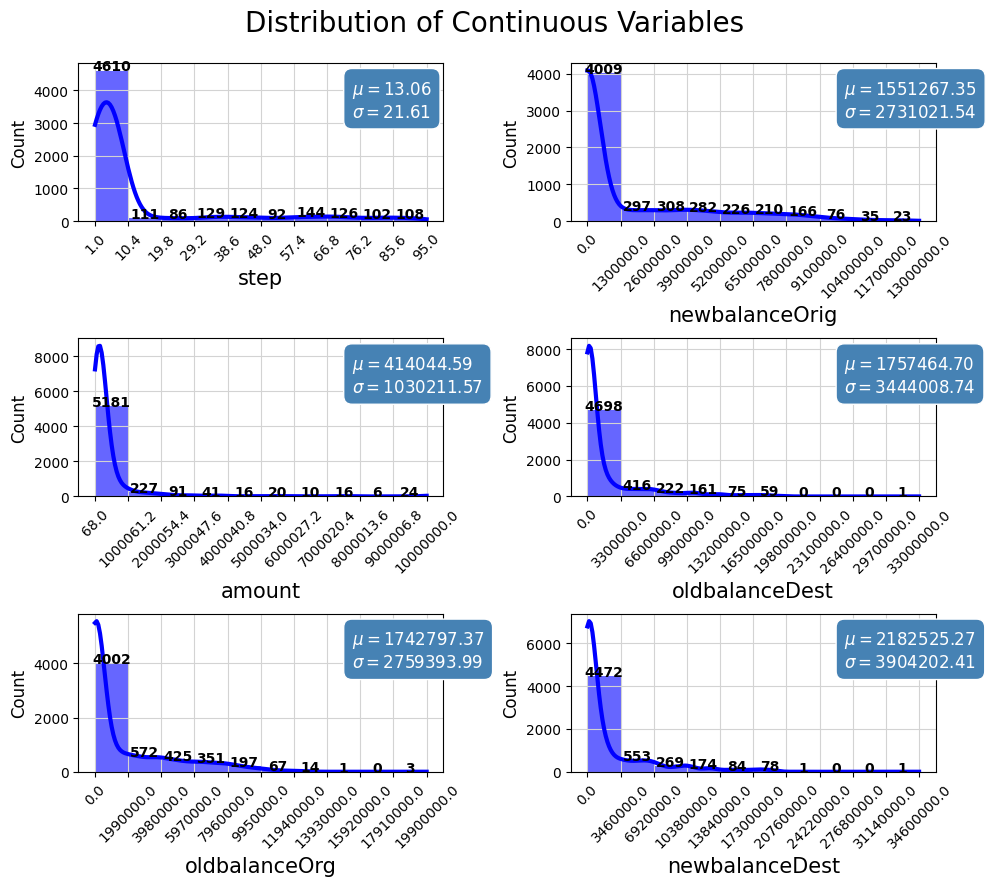

In [ ]:
# Filter out continuous features for the univariate analysis
continuous_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
df_continuous = df_filtered[continuous_features]

# Set up the subplot
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))

# Loop to plot histograms for each continuous feature
for i, col in enumerate(df_continuous.columns):
    y = i // 3
    x = i % 3
    values, bin_edges = np.histogram(df_continuous[col],
                                     range=(np.floor(df_continuous[col].min()), np.ceil(df_continuous[col].max())))

    graph = sns.histplot(data=df_continuous, x=col, bins=bin_edges, kde=True, ax=ax[x, y],
                         edgecolor='none', color='blue', alpha=0.6, line_kws={'lw': 3})
    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')

    for j, p in enumerate(graph.patches):
        ax[x, y].annotate('{}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                          ha='center', fontsize=10, fontweight="bold")

    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))
    ax[x, y].text(0.75, 0.9, textstr, transform=ax[x, y].transAxes, fontsize=12, verticalalignment='top',
                  color='white', bbox=dict(boxstyle='round', facecolor='steelblue', edgecolor='white', pad=0.5))

plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

* __Time (`step`)__: The distribution shows that the majority of transactions occur at the beginning of the period, with a long tail extending to later steps. In fraud detection, this could indicate that fraudulent activity may be more frequent at specific times or that a pattern of fraud evolves over time.
    
    
* __Transaction Amount (`amount`)__:  The graph shows that most transactions are for small amounts, which makes sense for everyday transactions. However, the presence of a few transactions with extremely large amounts (outliers) is a major red flag.
    
    
* __Sender's Transaction (`oldbalanceOrg` & `newbalanceOrig`)__: The distributions are highly concentrated near zero, which is expected since many transactions, especially for a large customer base, would involve small balances. The extremely high outliers are strong indicators of potential fraud. A sudden, massive change in balance or a transaction involving an unusually large account balance could be a key sign of an account takeover or other fraudulent activity.
    
    
* __Receiver's Transaction (`oldbalanceDest` & `newbalanceDest`)__: Similar to the source balances, the distributions are also heavily right-skewed and have significant outliers. A large amount being transferred into or out of an account with a previously low or zero balance, especially for a destination account that is not a known customer, could be a strong signal of fraudulent activity.

____

The univariate analysis highlights that all continuous features have distributions that are far from normal. This is a blessing in disguise for fraud detection because **fraudulent transactions are, by their nature, anomalous**. The extreme values (outliers) in **`amount`, `newbalanceOrig`,** and  **`newbalanceDest`** are likely the very signals that will allow a **machine learning model to distinguish fraudulent transactions from legitimate ones**.

####4.1.2. Categorical Variables Univariate Analysis

In [ ]:
# Filter out categorical features for the univariate analysis
categorical_features = ['type','isFraud']
df_categorical = df_filtered[categorical_features]

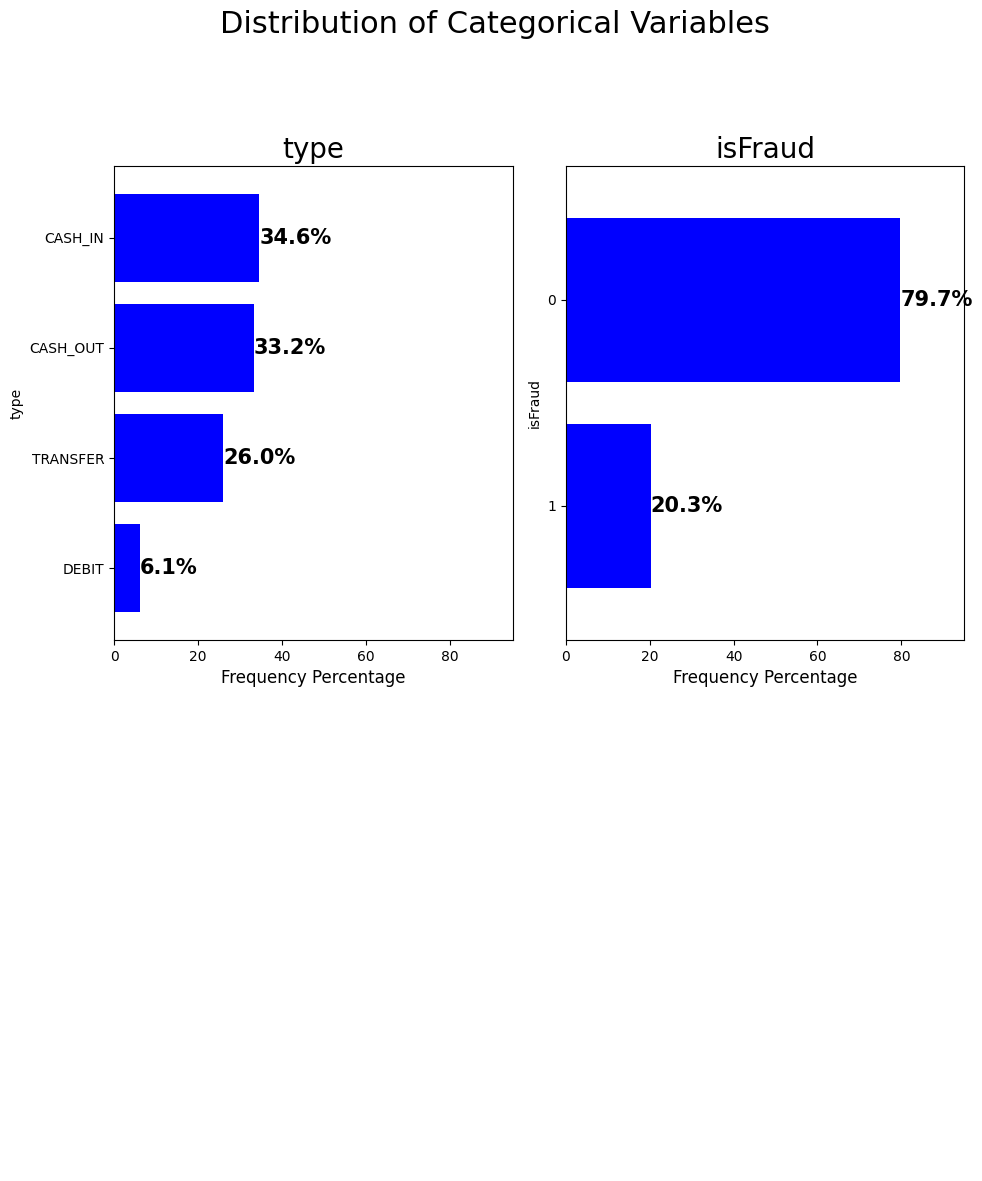

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 12))

# Loop to plot bar charts for each categorical feature in the 4x2 layout
for i, col in enumerate(categorical_features):
    row = i // 2
    col_idx = i % 2

    # Calculate frequency percentages
    value_counts = df_filtered[col].value_counts(normalize=True).mul(100).sort_values()

    # Plot bar chart
    value_counts.plot(kind='barh', ax=ax[row, col_idx], width=0.8, color='blue')

    # Add frequency percentages to the bars
    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(value, index, str(round(value, 1)) + '%', fontsize=15, weight='bold', va='center')

    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(f'{col}', fontsize=20)

ax[1,0].axis('off')
ax[1,1].axis('off')
plt.suptitle('Distribution of Categorical Variables', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

* __Transaction Type (`type`)__: The plot shows that CASH_IN (34.6%) and CASH_OUT (33.2%) are the most frequent transaction types, together accounting for over two-thirds of all transactions. TRANSFER (26.0%) is also a significant type, while DEBIT (6.1%) is relatively rare.
    
    
* __No. of Fraud (`isFraud`)__:  A massive 79.7% of transactions are legitimate (isFraud = 0), while only 20.3% are fraudulent (isFraud = 1).
    
    
____
 The **`isFraud`** variable is severely **imbalanced**, this is a crucial finding, as **machine learning models** trained on such imbalanced data can be **biased towards the majority class (legitimate transactions)**, potentially failing to correctly identify fraudulent ones.

###4.2. Bivariate Analysis

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

For our __bivariate analysis__ on the dataset's features with respect to the target variable:

* For __continuous data__: I am going to use __bar plots__ to showcase the average value of each feature for the different target classes, and __KDE plots__ to understand the distribution of each feature across the target classes. This aids in discerning how each feature varies between the two target outcomes.

    
* For __categorical data__: I am going to employ __100% stacked bar plots__ to depict the proportion of each category across the target classes. This offers a comprehensive view of how different categories within a feature relate to the target.

Through these visualization techniques, we are going to gain a deeper understanding of the relationship between individual features and the target, revealing potential predictors for heart disease.

####4.2.1. Numerical Variables Bivariate Analysis

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">
    
I am going to visualize each continuous feature against the target using two types of charts:

* __Bar plots__ - showing the mean values.
* __KDE plots__ - displaying the distribution for each target category.

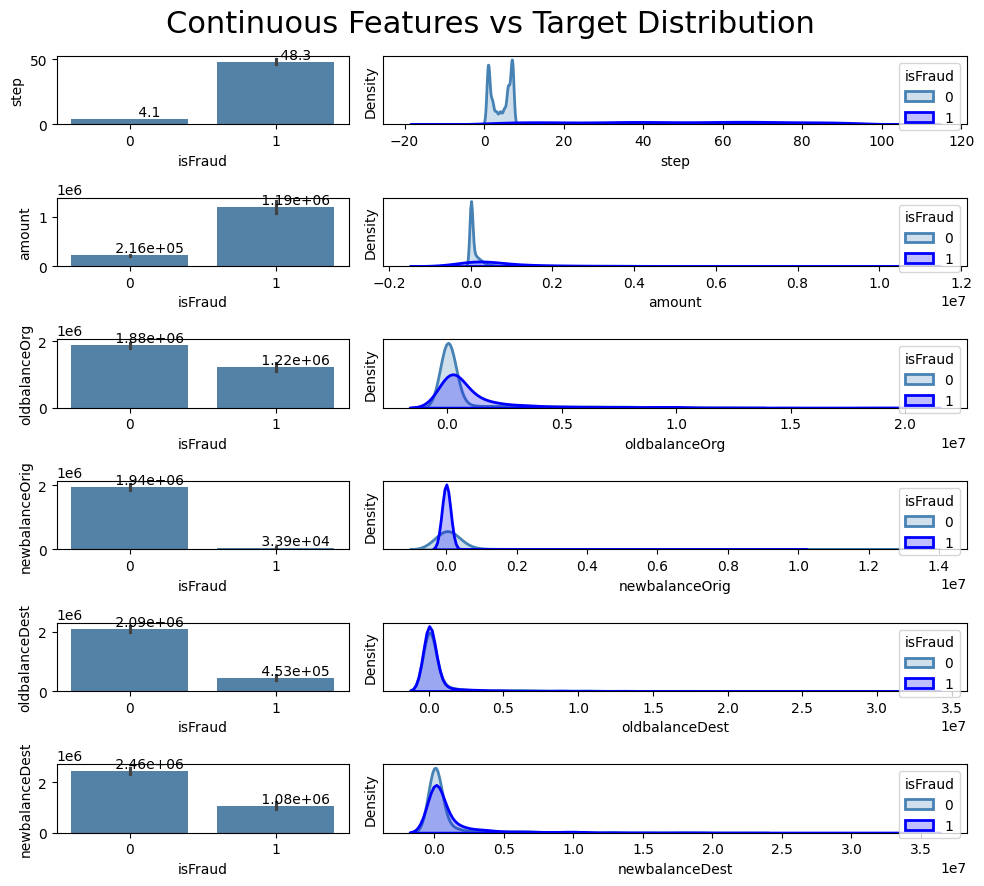

In [ ]:
# Set color palette
sns.set_palette(['steelblue', 'blue'])

# Create the subplots
fig, ax = plt.subplots(len(continuous_features), 2, figsize=(10,9), gridspec_kw={'width_ratios': [1, 2]})

# Loop through each continuous feature to create barplots and kde plots
for i, col in enumerate(continuous_features):
    # Barplot showing the mean value of the feature for each target category
    graph = sns.barplot(data=df_filtered, x="isFraud", y=col, ax=ax[i,0])

    # KDE plot showing the distribution of the feature for each target category
    sns.kdeplot(data=df[df["isFraud"]==0], x=col, fill=True, linewidth=2, ax=ax[i,1], label='0')
    sns.kdeplot(data=df[df["isFraud"]==1], x=col, fill=True, linewidth=2, ax=ax[i,1], label='1')
    ax[i,1].set_yticks([])
    ax[i,1].legend(title='isFraud', loc='upper right')

    # Add mean values to the barplot
    for cont in graph.containers:
        graph.bar_label(cont, fmt='         %.3g')

# Set the title for the entire figure
plt.suptitle('Continuous Features vs Target Distribution', fontsize=22)
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

* __Time (`step`)__: The average step for fraudulent transactions is much higher (48.3) than for non-fraudulent ones (4.1). The KDE plot confirms this, showing that legitimate transactions are heavily concentrated in the early steps, while fraudulent ones are spread out and occur much later. This suggests that fraud isn't an immediate event but a pattern that emerges over time.
    
    
* __Transaction Amount (`amount`)__:  This is a powerful predictor. The average amount for fraudulent transactions is over 1.19 million, which is significantly higher than the average for legitimate transactions (216,000). The KDE plot shows two very different distributions: non-fraudulent transactions are heavily concentrated at low amounts, while fraudulent transactions are spread across a much wider range of higher values.
    
* __Sender's Transaction (`oldbalanceOrg` & `newbalanceOrig`)__: Legitimate transactions typically involve high original balances (average of 1.88 million). In contrast, fraudulent transactions occur with a much lower average original balance of 1.22 million. However, the newbalanceOrig tells a different story: non-fraudulent transactions have a high average new balance, but for fraudulent ones, the average new balance is near zero (~33,900). This suggests that fraudulent activity often involves a nearly complete transfer of funds out of an account, leaving a very low new balance.
    
    
* __Receiver's Transaction (`oldbalanceDest` & `newbalanceDest`)__:These variables show a stark contrast. The destination accounts for legitimate transactions have a high average original balance (2.99 million), which remains high after the transaction. However, fraudulent transactions are often directed to accounts with very low initial balances (463,000) that then receive a large sum, resulting in a significantly higher new balance (1.08 million). This pattern—a large transfer into an account with a low or zero balance—is a classic indicator of money laundering or fraud.

____

The Bivariate Analysis of continuous features against the isFraud target reveals highly actionable insights. The distributions of fraudulent and non-fraudulent transactions are remarkably different across all variables.

The most powerful fraud signals are:

 1. **Time:** Fraudulent transactions occur later in the dataset (step).

 2. **Amount:** They involve significantly higher transaction amounts.

 3. **Balance Discrepancies:** They are characterized by a drastic reduction in the source account's balance (oldbalanceOrig to newbalanceOrig) and a substantial increase in the destination account's balance from a low starting point (oldbalanceDest to newbalanceDest).

####4.2.2. Categorical Variables Bivariate Analysis

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

I am going to display __100% stacked bar plots__ for each categorical feature illustrating the proportion of each category across the two target classes, complemented by the exact counts and percentages on the bars.

In [ ]:
CatF = [f for f in categorical_features if f != 'isFraud']

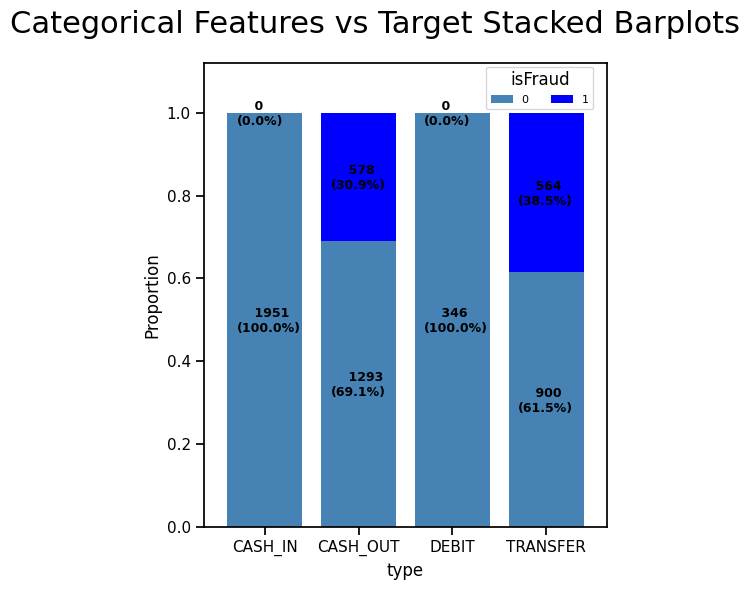

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,6))

for i,col in enumerate(CatF):

    # Create a cross tabulation showing the proportion of purchased and non-purchased loans for each category of the feature
    cross_tab = pd.crosstab(index=df_filtered[col], columns=df['isFraud'])

    # Using the normalize=True argument gives us the index-wise proportion of the data
    cross_tab_prop = pd.crosstab(index=df_filtered[col], columns=df['isFraud'], normalize='index')

    # Define colormap
    cmp = ListedColormap(['steelblue', 'blue'])

    # Plot stacked bar charts
    cross_tab_prop.plot(kind='bar', ax=ax, stacked=True, width=0.8, colormap=cmp,
                        legend=False, ylabel='Proportion', sharey=True)

    # Add the proportions and counts of the individual bars to our plot
    for idx, val in enumerate([*cross_tab.index.values]):
        for (proportion, count, y_location) in zip(cross_tab_prop.loc[val],cross_tab.loc[val],cross_tab_prop.loc[val].cumsum()):
            ax.text(x=idx-0.3, y=(y_location-proportion)+(proportion/2)-0.03,
                         s = f'    {count}\n({np.round(proportion * 100, 1)}%)',
                         color = "black", fontsize=9, fontweight="bold")

    # Add legend
    ax.legend(title='isFraud', loc=(0.7,0.9), fontsize=8, ncol=2)
    # Set y limit
    ax.set_ylim([0,1.12])
    # Rotate xticks
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


plt.suptitle('Categorical Features vs Target Stacked Barplots', fontsize=22)
plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

The stacked bar chart shows a clear relationship between the type of transaction and the proportion of fraudulent activities.


*   **CASH_IN and PAYMENT have 0% Fraud:** The most significant finding is that CASH_IN and PAYMENT transaction types have zero fraudulent cases in the dataset. This is a powerful insight. It suggests that fraud does not occur when money is being credited to an account (CASH_IN) or when a payment is being made (which might be a one-to-one transfer of funds to a verified vendor).
*   **DEBIT also has 0% Fraud:** The DEBIT transaction type, which represents a small portion of the overall transactions, also shows zero fraud.
* **CASH_OUT and TRANSFER are associated with Fraud:** In stark contrast, CASH_OUT and TRANSFER transactions are where all fraudulent activity is concentrated.

    *  **CASH_OUT** transactions have a fraud rate of **30.9%** (578 out of 1,871).

    *  **TRANSFER** transactions have the highest fraud rate at **38.5%**(564 out of 1,464).



###4.3. Multivariate Analysis

In [ ]:
corr = df [['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']].corr()

In [ ]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.323943,-0.007816,0.094117,0.227413,0.435490
oldbalanceOrg,0.323943,1.000000,0.937024,0.207628,0.209787,0.046445
newbalanceOrig,-0.007816,0.937024,1.000000,0.234148,0.190314,-0.127912
oldbalanceDest,0.094117,0.207628,0.234148,1.000000,0.928831,-0.056575
newbalanceDest,0.227413,0.209787,0.190314,0.928831,1.000000,-0.002864
isFraud,0.435490,0.046445,-0.127912,-0.056575,-0.002864,1.000000


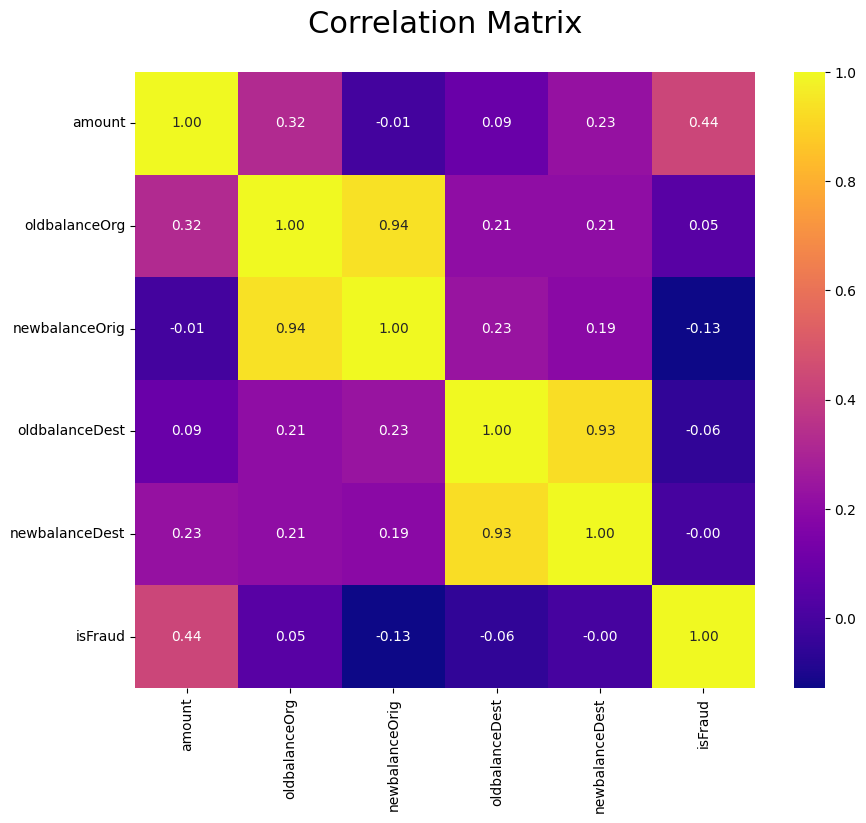

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='plasma', fmt='.2f')
plt.title('Correlation Matrix',y=1.05, size=22)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h2 align="left"><font color=red>Inferences:</font></h2>

* __High Positive Correlation on Target: `Amount`__
* __Moderate Positive Correlation on Target: `Old Balance Origin`__
* __High Negative Correlation on Target: `New Balance Origin`__
* __Moderate Negative Correlation on Target: `Old Balance Destination`__
* __Less Correlation on Target: `New Balance Destination`__

---



##Step 5 :- Data Preprocessing

###5.1. Irrelevent Features Removal

After performing detailed EDA, I found that variable __'nameOrg'__ and __'nameDest'__ are irrelvent features, not reqired for ML model building








In [ ]:
#droping the irrelevent feature
df_filtered.drop(columns=['nameOrig','nameDest'], inplace=True)

In [ ]:
df_filtered.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1


Hence __'nameOrig'__ & __'nameDest'__ are droped

---



###5.2. Missing Value Treatment

In [ ]:
df_filtered.isnull().sum().sum()

np.int64(0)

Upon our above inspection, it is obvious that there are no missing values in our dataset. This is ideal as it means we don't have to make decisions about imputation or removal, which can introduce bias or reduce our already limited dataset size.

---



###5.3. Outlier Treatment

I am going to check for outliers using the __IQR method__ for the continuous features:

In [ ]:
continuous_features

['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest']

In [ ]:
Q1 = df_filtered[continuous_features].quantile(0.25)
Q3 = df_filtered[continuous_features].quantile(0.75)
IQR = Q3 - Q1
Outlier_count = ((df_filtered[continuous_features] < (Q1 - 1.5 * IQR)) | (df_filtered[continuous_features] > (Q3 + 1.5 * IQR))).sum()

Outlier_count

,0
step,975
amount,601
oldbalanceOrg,488
newbalanceOrig,658
oldbalanceDest,925
newbalanceDest,888


Upon identifying outliers for the specified continuous features, we found the following:

* __`step`__: 975 outliers
* __`amount`__: 601 outliers
* __`oldbalanceOrg`__: 488 outlier
* __`newbalanceOrig`__: 658 outliers
* __`oldbalanceDest`__: 925 outliers
* __`newbalanceDest`__: 888 outliers

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>ML Models Sensitive to Outliers:</font></h3>

| Model                                                  | Why Sensitive (short & crisp)                                                                                                                                 |
| ------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Logistic Regression                                    | Uses a linear decision boundary; outliers in feature space or mislabeled<br> points can shift the boundary significantly. (“Margin disruption”) |
| Support Vector Machine (standard, soft or hard margin) | Outliers near or on the wrong side of margin force the hyperplane to <br>move, shrinking margin; high penalty parameter (C) exacerbates this.   |
| k-Nearest Neighbors (k-NN)                             | Decisions depend directly on closest points; if outliers are among nearest<br> neighbors, they influence classification of nearby points.      |
| AdaBoost / Boosting Methods                            | Boosting focuses more and more on misclassified samples; outliers often <br>misclassified → get high weight → model may overfit them.    |


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

<h3 align="left"><font color=red>Approaches for Outlier Treatment:</font></h3>
    
* __Removal of Outliers__: Directly discard data points that fall outside of a defined range, typically based on a method like the Interquartile Range (IQR).

    
* __Capping Outliers__: Instead of removing, we can limit outliers to a certain threshold, such as the 1st or 99th percentile.
    
    
* __Transformations__: Applying transformations like log or Box-Cox can reduce the impact of outliers and make the data more Gaussian-like.
    
    
* __Robust Scaling__: Techniques like the RobustScaler in Scikit-learn can be used, which scales features using statistics that are robust to outliers.

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h3 align="left"><font color=red>Conclusion:</font></h3>

Given __the nature of the algorithms__ and __the small size of our dataset__, direct removal of outliers might not be the best approach. Instead, __we'll focus on applying transformations like Box-Cox in the subsequent steps__ to reduce the impact of outliers and make the data more suitable for modeling.



---

###5.4. Categorical Features Encoding

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:112%; text-align:left">

<h3 align="left"><font color=red>One-hot Encoding Decision:</font></h3>
    
Based on the feature descriptions, let's decide on one-hot encoding:

1. __Nominal Variables__: These are variables with no inherent order. They should be one-hot encoded because using them as numbers might introduce an unintended order to the model.

2. __Ordinal Variables__: These variables have an inherent order. They don't necessarily need to be one-hot encoded since their order can provide meaningful information to the model.

Given the above explanation:

- __`type`__: This variable represents type of Transactions, such as "CASH_IN", "CASH_OUT", "TRANSFER" etc, which seems to be nominal nature and hence require one-hot encoding

In [ ]:
# Implementing one-hot encoding on the specified categorical features
df_encoded = pd.get_dummies(df_filtered, columns=['type'], drop_first=True)
df_encoded[['type_CASH_OUT','type_DEBIT','type_TRANSFER']] = df_encoded[['type_CASH_OUT','type_DEBIT','type_TRANSFER']].astype('uint8')

#Converting target variable i.e. isFraud into integer type for further analysis
df_encoded['isFraud'] = df_encoded['isFraud'].astype('int64')

In [ ]:
df_encoded.dtypes

,0
step,int64
amount,float64
oldbalanceOrg,float64
newbalanceOrig,float64
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64
type_CASH_OUT,uint8
type_DEBIT,uint8
type_TRANSFER,uint8


In [ ]:
df_encoded.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_TRANSFER
0,1,181.0,181.0,0.0,0.0,0.0,1,0,0,1
1,1,181.0,181.0,0.0,21182.0,0.0,1,1,0,0
2,1,2806.0,2806.0,0.0,0.0,0.0,1,0,0,1
3,1,2806.0,2806.0,0.0,26202.0,0.0,1,1,0,0
4,1,20128.0,20128.0,0.0,0.0,0.0,1,0,0,1




---



###5.5. Feature Scaling

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

__Feature Scaling__ is a crucial preprocessing step __for algorithms that are sensitive to the magnitude or scale of features__. Models like __SVM__, __LR__, __KNN__,and many linear models rely on distances or gradients, making them susceptible to variations in feature scales. __Scaling ensures that all features contribute equally to the model's decision rather than being dominated by features with larger magnitudes.__

____
<h3 align="left"><font color=red>Why We Skip It Now:</font></h3>

While feature scaling is vital for some models, not all algorithms require scaled data. For instance, __Decision Tree-based models__ are scale-invariant. Given our intent to use a mix of models (some requiring scaling, others not), __we've chosen to handle scaling later using pipelines__. This approach lets us apply scaling specifically for models that benefit from it, ensuring flexibility and efficiency in our modeling process.


---



###5.6. Transforming Skewed Features

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">

__Box-Cox__ transformation is a powerful method to stabilize variance and make the data more normal-distribution-like. It's particularly useful when you're unsure about the exact nature of the distribution you're dealing with, as it can adapt itself to the best power transformation. However, the Box-Cox transformation only works for positive data, so one must be cautious when applying it to features that contain zeros or negative values.

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">
    
<h3 align="left"><font color=red>Transforming Skewed Features & Data Leakage Concerns:</font></h3>
    
When preprocessing data, especially applying transformations like the Box-Cox, it's essential to be wary of __data leakage__. __Data leakage__ refers to a mistake in the preprocessing of data in which information from outside the training dataset is used to transform or train the model. This can lead to overly optimistic performance metrics.


<h3 align="left"><font color=red>To avoid data leakage and ensure our model generalizes well to unseen data:</font></h3>

__1- Data Splitting:__ We'll first split our dataset into a training set and a test set. This ensures that we have a separate set of data to evaluate our model's performance, untouched during the training and preprocessing phases.

__2- Box-Cox Transformation:__ We'll examine the distribution of the continuous features in the training set. If they appear skewed, we'll apply the Box-Cox transformation to stabilize variance and make the data more normal-distribution-like. Importantly, we'll determine the Box-Cox transformation parameters solely based on the training data.

__3- Applying Transformations to Test Data:__ Once our transformation parameters are determined from the training set, we'll use these exact parameters to transform our validation/test set. This approach ensures that no information from the validation/test set leaks into our training process.

__4. Hyperparameter Tuning & Cross-Validation:__ Given our dataset's size, to make the most of the available data during the model training phase, we'll employ __cross-validation on the training set for hyperparameter tuning__. This allows us to get a better sense of how our model might perform on unseen data, without actually using the test set. The test set remains untouched during this phase and is only used to evaluate the final model's performance.


By following this structured approach, we ensure a rigorous training process, minimize the risk of data leakage, and set ourselves up to get a realistic measure of our model's performance on unseen data.

In [ ]:
# Define the features (X) and the output labels (y)
x = df_encoded.drop('isFraud', axis=1)
y = df_encoded['isFraud']

In [ ]:
# Splitting data into train and test sets
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
continuous_features

['step',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest']

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">
    
The Box-Cox transformation requires all data to be strictly positive. To transform the `step`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` feature using Box-Cox, we can add a small constant (e.g., 0.001) to ensure all values are positive:

In [ ]:
# Adding a small constant to 'oldpeak' to make all values positive
xtrain['step'] = xtrain['step'] + 0.001
xtrain['oldbalanceOrg'] = xtrain['oldbalanceOrg'] + 0.001
xtrain['newbalanceOrig'] = xtrain['newbalanceOrig'] + 0.001
xtrain['oldbalanceDest'] = xtrain['oldbalanceDest'] + 0.001
xtrain['newbalanceDest'] = xtrain['newbalanceDest'] + 0.001

xtest['step'] = xtest['step'] + 0.001
xtest['oldbalanceOrg'] = xtest['oldbalanceOrg'] + 0.001
xtest['newbalanceOrig'] = xtest['newbalanceOrig'] + 0.001
xtest['oldbalanceDest'] = xtest['oldbalanceDest'] + 0.001
xtest['newbalanceDest'] = xtest['newbalanceDest'] + 0.001

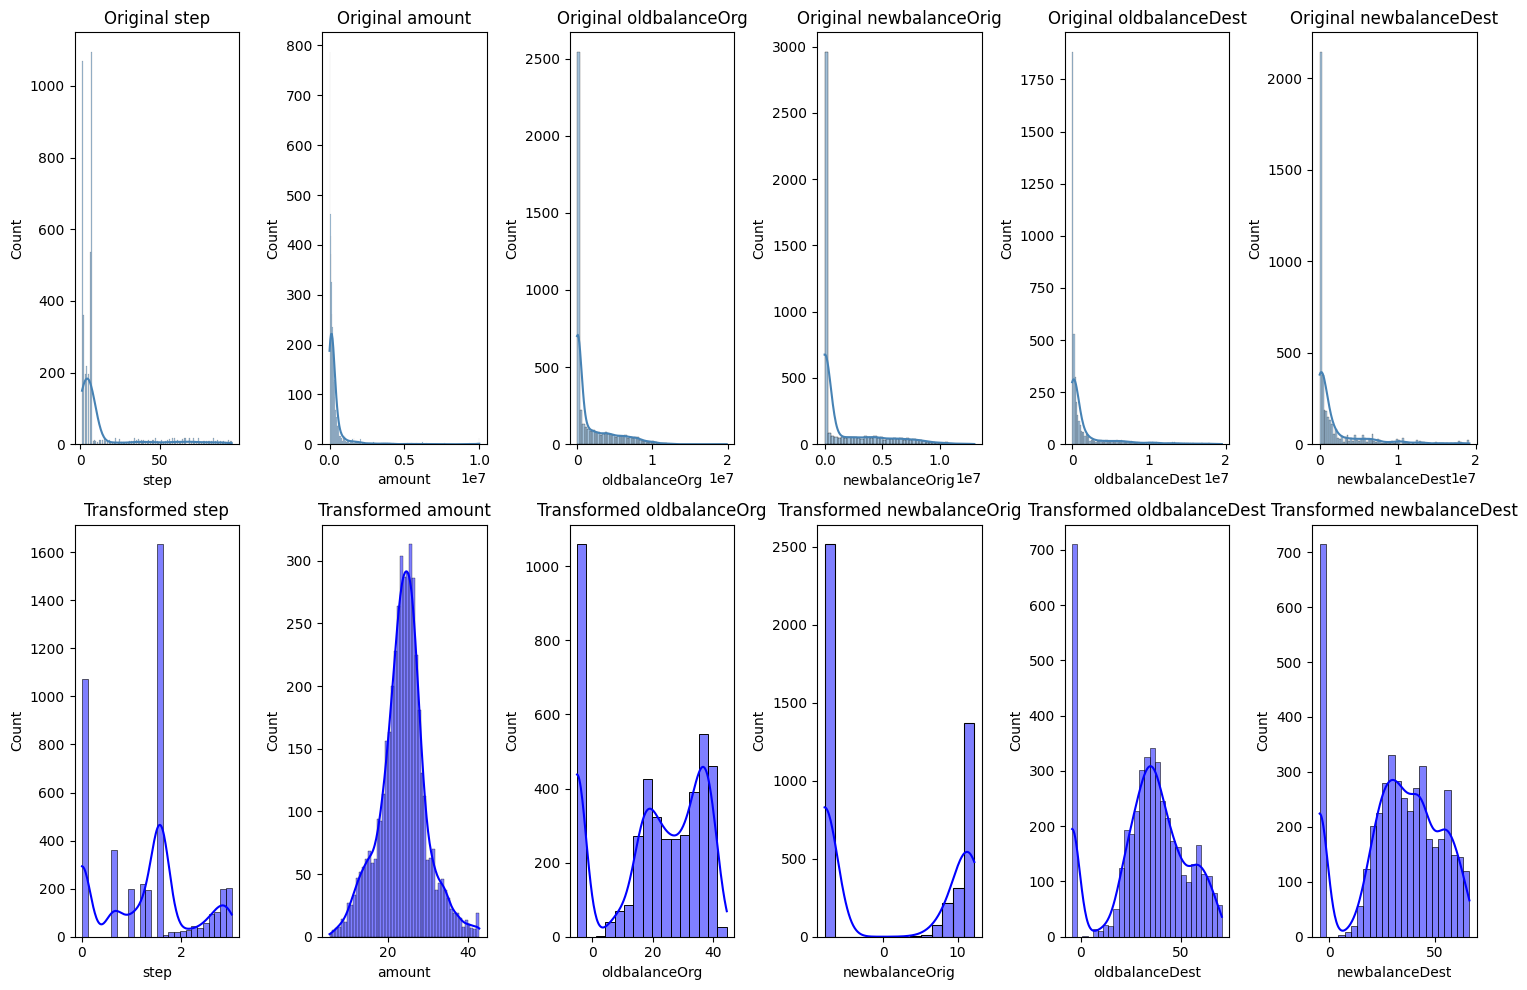

In [ ]:
# Checking the distribution of the continuous features
fig, ax = plt.subplots(2, 6, figsize=(15,10))

# Original Distributions
for i, col in enumerate(continuous_features):
    sns.histplot(xtrain[col], kde=True, ax=ax[0,i], color='steelblue').set_title(f'Original {col}')


# Applying Box-Cox Transformation
# Dictionary to store lambda values for each feature
lambdas = {}

for i, col in enumerate(continuous_features):
    # Only apply box-cox for positive values
    if xtrain[col].min() > 0:
        xtrain[col], lambdas[col] = boxcox(xtrain[col])
        # Applying the same lambda to test data
        xtest[col] = boxcox(xtest[col], lmbda=lambdas[col])
        sns.histplot(xtrain[col], kde=True, ax=ax[1,i], color='blue').set_title(f'Transformed {col}')
    else:
        sns.histplot(xtrain[col], kde=True, ax=ax[1,i], color='green').set_title(f'{col} (Not Transformed)')

fig.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">
    
<h2 align="left"><font color=red>Inference:</font></h2>

 The transformation successfully addresses the extreme right skew and outlier issues seen in the original, untransformed plots.

* __step__: The original step variable was highly skewed to the right. After the transformation, the distribution is much more symmetrical and appears to have multiple peaks. This suggests that the time step data may have underlying clusters or groups, which were obscured by the extreme skew. This normalized data would be better suited for most machine learning algorithms.

* __amount__: The original amount variable had an extremely long tail due to a few very large transactions. The transformed plot shows a distribution that is much closer to a bell curve (a normal distribution), with a clear peak and a more balanced spread. This transformation makes the amount feature more stable and less sensitive to outliers, which is crucial for model training.

* __oldbalanceOrig__ & __newbalanceOrig__: These balance variables, originally highly skewed, now show distributions that are more complex but significantly less skewed. They exhibit a prominent peak around zero, followed by a second, smaller peak. This could indicate a bimodal distribution, possibly separating transactions from accounts with an initial balance near zero from those with a substantial balance. The transformation makes these patterns more visible.

* __oldbalanceDest__ & __newbalanceDest__: The transformation has effectively reduced the skew in these destination balance variables. Similar to the source balances, the transformed distributions reveal a clear peak at a low value and other, less distinct peaks. This suggests that the Box-Cox transformation has not only normalized the data but also helped uncover latent patterns or clusters related to the destination accounts' balances.

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:115%; text-align:left">
    
<h2 align="left"><font color=red>Conclusion:</font></h2>

Transforming features to be more normal-like primarily helps in mitigating the impact of outliers, which is particularly beneficial for distance-based algorithms like __SVM__ and __KNN__. By reducing the influence of __outliers__, we ensure that these algorithms can compute distances more effectively and produce more reliable results.

In [ ]:
xtrain.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_TRANSFER
5573,1.214739,24.276278,29.027318,10.724112,36.573481,31.736351,0,0,0
2989,0.000999,15.463210,-4.960691,-7.881660,30.584548,11.053406,1,0,0
3153,0.000999,20.165802,24.241174,9.939438,-4.385317,-4.447645,0,0,0
3388,0.000999,23.016582,35.791142,11.546585,42.031315,38.860362,0,0,0
9718,1.619086,18.103148,32.200545,11.054651,38.514018,38.660196,1,0,0




---
##Step 6 :- Predective Modeling - ML Algorithms


ML Models to be use:
* Logistic Regression(LR)
* Decision Tree(DT)
* Random Forest(RF)
* Support Vector Machine(SVM)
And their Comparison.

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

__🔍<span style="font-size:130%; color:red"> Note: </span>__ In Financial Transaction scenarios, especially in the context of Fraud Detection, it's often more important __to have a high Precision__. A high precision ensures that legitimate transactions are not flagged as fraud, as that will effect the trust and customer annoyance will effect the business

###6.1. Evaluation Module

In [ ]:
# Creating a Evaluation Module for ML Models
def evaluate_model(model, xtest, ytest, model_name):
  ypred = model.predict(xtest)

  class_report = classification_report(ytest, ypred, output_dict= True)
  metrics ={
      "Precision_NonFraud": class_report["0"]["precision"],
        "Precision_Fraud": class_report["1"]["precision"],
        "Recall_NonFraud": class_report["0"]["recall"],
        "Recall_Fraud": class_report["1"]["recall"],
        "F1Score_NonFraud": class_report["0"]["f1-score"],
        "F1Score_Fraud": class_report["1"]["f1-score"],
        "Accuracy": accuracy_score(ytest, ypred)
  }
  d = pd.DataFrame(metrics, index=[model_name]).round(2)
  return d

###6.2. Logistic Regression (LR) Evaluation

In [ ]:
# Define the base logistic model and set up the pipeline with scaling
LR_Pipeline = Pipeline([
    ('scaler', StandardScaler()),
     ('lr', LogisticRegression(class_weight = 'balanced'))
     ])
LR_Pipeline.fit(xtrain, ytrain)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(class_weight='balanced'))])

In [ ]:
# Evaluation of the model on the test data
LR_evaluation = evaluate_model(LR_Pipeline, xtest, ytest, 'Logistic Regression')
LR_evaluation

,Precision_NonFraud,Precision_Fraud,Recall_NonFraud,Recall_Fraud,F1Score_NonFraud,F1Score_Fraud,Accuracy
Logistic Regression,0.99,0.93,0.98,0.96,0.98,0.95,0.98


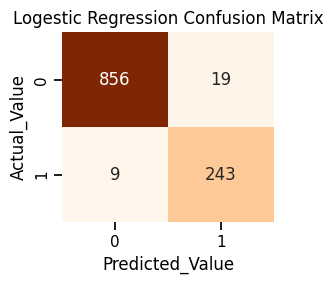

In [ ]:
# Plotting the Confusion Matrix
cm_LR = confusion_matrix(ytest,LR_Pipeline.predict(xtest))
plt.figure(figsize=(3, 3))
sns.set_context('notebook',font_scale = 1)
sns.heatmap(cm_LR,annot=True,fmt='d', cmap="Oranges", cbar=False)
plt.title('Logestic Regression Confusion Matrix');
plt.xlabel("Predicted_Value")
plt.ylabel("Actual_Value")
plt.tight_layout()

###6.3. Decision Tree (DT) Evaluation

In [ ]:
# Define the base Decision Tree model
DT = DecisionTreeClassifier(class_weight = 'balanced')
DT.fit(xtrain, ytrain)

DecisionTreeClassifier(class_weight='balanced')

In [ ]:
# Evaluation of the model on the test data
DT_evaluation = evaluate_model(DT, xtest, ytest, 'Decision Tree')
DT_evaluation

,Precision_NonFraud,Precision_Fraud,Recall_NonFraud,Recall_Fraud,F1Score_NonFraud,F1Score_Fraud,Accuracy
Decision Tree,0.99,0.98,1.0,0.97,0.99,0.98,0.99


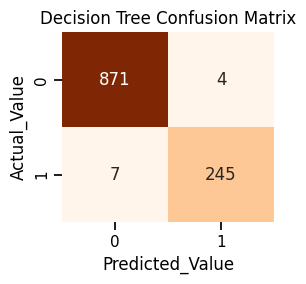

In [ ]:
# Plotting the Confusion Matrix
cm_DT = confusion_matrix(ytest,DT.predict(xtest))
plt.figure(figsize=(3, 3))
sns.set_context('notebook',font_scale = 1)
sns.heatmap(cm_DT,annot=True,fmt='d', cmap="Oranges", cbar=False)
plt.title('Decision Tree Confusion Matrix');
plt.xlabel("Predicted_Value")
plt.ylabel("Actual_Value")
plt.tight_layout()

###6.4. Random Forest (RF) Evaluation

In [ ]:
# Define the base Random Forest model
RF = RandomForestClassifier(class_weight = 'balanced')
RF.fit(xtrain, ytrain)

RandomForestClassifier(class_weight='balanced')

In [ ]:
# Evaluation of the model on the test data
RF_evaluation = evaluate_model(RF, xtest, ytest, 'Random Forest')
RF_evaluation

,Precision_NonFraud,Precision_Fraud,Recall_NonFraud,Recall_Fraud,F1Score_NonFraud,F1Score_Fraud,Accuracy
Random Forest,0.99,1.0,1.0,0.97,0.99,0.98,0.99


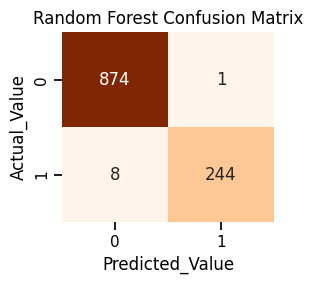

In [ ]:
# Plotting the Confusion Matrix
cm_RF = confusion_matrix(ytest,RF.predict(xtest))
plt.figure(figsize=(3, 3))
sns.set_context('notebook',font_scale = 1)
sns.heatmap(cm_RF,annot=True,fmt='d', cmap="Oranges", cbar=False)
plt.title('Random Forest Confusion Matrix');
plt.xlabel("Predicted_Value")
plt.ylabel("Actual_Value")
plt.tight_layout()

###6.5. Support Vector Machine (SVM) Evaluation

In [ ]:
# Define the base logistic model and set up the pipeline with scaling
SVM_Pipeline = Pipeline([
    ('scaler', StandardScaler()),
     ('svm', SVC(class_weight = 'balanced'))
     ])
SVM_Pipeline.fit(xtrain, ytrain)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(class_weight='balanced'))])

In [ ]:
# Evaluation of the model on the test data
SVM_evaluation = evaluate_model(SVM_Pipeline, xtest, ytest, 'SVM')
SVM_evaluation

,Precision_NonFraud,Precision_Fraud,Recall_NonFraud,Recall_Fraud,F1Score_NonFraud,F1Score_Fraud,Accuracy
SVM,1.0,0.98,1.0,0.98,1.0,0.98,0.99


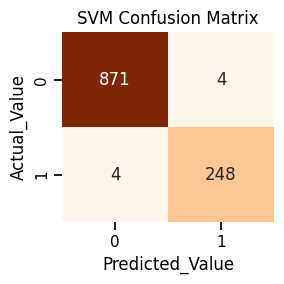

In [ ]:
# Plotting the Confusion Matrix
cm_SVM = confusion_matrix(ytest,SVM_Pipeline.predict(xtest))
plt.figure(figsize=(3, 3))
sns.set_context('notebook',font_scale = 1)
sns.heatmap(cm_SVM,annot=True,fmt='d', cmap="Oranges", cbar=False)
plt.title('SVM Confusion Matrix');
plt.xlabel("Predicted_Value")
plt.ylabel("Actual_Value")
plt.tight_layout()

###6.6. ML Model Performance Comparison

In [ ]:
# Creating a Comparison Table based on Evaluation Metrics
Evaluation = pd.concat([DT_evaluation, RF_evaluation, LR_evaluation, SVM_evaluation], axis=0).sort_values(by='Precision_Fraud', ascending=False)
print('ML Model Comparison Table')
Evaluation

ML Model Comparison Table


,Precision_NonFraud,Precision_Fraud,Recall_NonFraud,Recall_Fraud,F1Score_NonFraud,F1Score_Fraud,Accuracy
Random Forest,0.99,1.00,1.00,0.97,0.99,0.98,0.99
Decision Tree,0.99,0.98,1.00,0.97,0.99,0.98,0.99
SVM,1.00,0.98,1.00,0.98,1.00,0.98,0.99
Logistic Regression,0.99,0.93,0.98,0.96,0.98,0.95,0.98


<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">
    
<h2 align="left"><font color=red>Inference:</font></h2>

In the Fraud Detection Analysis, our primary objective is __to ensure a high Precision for the positive class__. It's imperative to accurately identify every potential Fraud cases and not flagging Legitimate Transaction as Fraud. Along with that we should not miss any Fraud Transaction, so balance between precision and recall is also important, i.e. __F1-Score__.
<br>__Random Forest__ model has more precision and F1-Score compare to other, hence it is going to use for fraud prediction



##Step 7 :- Financial Impact Analysis

In [ ]:
# Printing Confusion Matrix
cm_RF

array([[874,   1],
       [  8, 244]])

In [ ]:
# Estimated Saving Analysis
cost_review = 50 # concidering 50 bucks as cost for reviewing flagged legitimate trasaction
FN_count = cm_RF[1][0]
FP_count = cm_RF[0][1]
avg_fraud_amt = df_filtered[df_filtered['isFraud']==1]['amount'].mean()
Exp_loss = FN_count * avg_fraud_amt
cost_FP = FP_count*cost_review
Net_loss = Exp_loss + cost_FP
Baseline_loss = df_filtered[df_filtered['isFraud']==1]['amount'].sum()
est_save = Baseline_loss - Net_loss
print('No. of Frauds missed :',FN_count)
print('No. of Legitimate transaction Flagged:',FP_count)
print('Average Fraud Amount:',avg_fraud_amt)
print('Expected Loss:',Exp_loss)
print('Cost of False Positive:',cost_FP)
print('Net Expected Loss:',Net_loss)
print('Baseline Loss:',Baseline_loss)
print('Estimated Savings:',est_save)

No. of Frauds missed : 8
No. of Legitimate transaction Flagged: 1
Average Fraud Amount: 1192628.9320753065
Expected Loss: 9541031.456602452
Cost of False Positive: 50
Net Expected Loss: 9541081.456602452
Baseline Loss: 1361982240.43
Estimated Savings: 1352441158.9733977


##Step 8 :- Conclusion

After implementing Random Forest Model and evaluating it, these are following Observation:
* Number of Fraud Transaction missed are 8
* Number of Legitimate Transaction flagged fraud is 1
* Net Expected Loss due to Model's error is 9.5 Million bucks
* Estimated Amount saved is 1.35 Billion bucks